Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

## Tablular joining practice

In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
# Load Zillow Housing Prices by Zip Code.csv
# Load tl_2025_us_zcta520.shp
zillow_df = pd.read_csv('/Users/cwharvey/odrive/Google Drive (UMD)/Teaching/URSP688Y Spring 2026/Data/688y_exercise03_data/exercise03_Noah/Zillow Housing Prices by Zip Code.csv')
zip_gdf = gpd.read_file('/Users/cwharvey/odrive/Google Drive (UMD)/Teaching/URSP688Y Spring 2026/Data/688y_exercise03_data/exercise03_Noah/tl_2025_us_zcta520.zip')

In [3]:
# Make sure zip codes are saved as strings in both dataframes
zillow_df.RegionName = zillow_df.RegionName.astype('string')
zip_gdf.GEOID20 = zip_gdf.GEOID20.astype('string')

In [ ]:
# Inner join/merge zillow data to zip code shapes
join_df = zip_gdf.merge(zillow_df, left_on='GEOID20', right_on='RegionName', how='inner')

In [7]:
# Note that the inner join greatly reduces the number of zipcodes we're working with.
# It only keeys the ones that are present in both datasets.
len(zip_gdf)

33791

In [8]:
len(join_df)

423

In [ ]:
# Now the zillow columns are joined to zip code table
join_df.head()

,ZCTA5CE20,GEOID20,GEOIDFQ20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry,RegionID,RegionName,State,City,CountyName,26-Feb
0,21874,21874,860Z200US21874,B5,G6350,S,73216870,111701,+38.3938409,-075.3520025,"POLYGON ((-75.40667 38.4154, -75.40666 38.4154...",67094,21874,MD,Willards,Wicomico County,282956
1,21912,21912,860Z200US21912,B5,G6350,S,87726123,4536007,+39.4194145,-075.8186317,"POLYGON ((-75.88381 39.36706, -75.88379 39.367...",67102,21912,MD,Warwick,Cecil County,557201
2,20854,20854,860Z200US20854,B5,G6350,S,87668199,7842307,+39.0327720,-077.2208298,"POLYGON ((-77.3167 39.07197, -77.31522 39.0747...",66668,20854,MD,Potomac,Montgomery County,1272060
3,21769,21769,860Z200US21769,B5,G6350,S,103932566,661626,+39.4424641,-077.5689083,"POLYGON ((-77.64088 39.41539, -77.64078 39.415...",67028,21769,MD,Middletown,Frederick County,558919
4,21221,21221,860Z200US21221,B5,G6350,S,38932079,16318085,+39.2921246,-076.4369949,"POLYGON ((-76.5001 39.31328, -76.5 39.3135, -7...",66831,21221,MD,Essex,Baltimore County,288015


# Demo 10 - Spatial Visualization

Today we'll be talking about visualizing spatial data—making maps. Like other data visualization in Python, mapping is essentially just drawing in Cartesian space. Maps, however, introduce some particularities around coordinate reference systems (projections). They can also be supplemented with base layers showing reference data. The ubiquity of web maps nowadays also compels us to develop interactive maps that let us pan, zoom, and click on objects to get more information. Luckily, some packages make developing maps with Python fairly straightforward, though it can still take some work to refine them visually.

In [10]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## GeoPandas `plot`

The simplest option for making a static map from a GeoDataFrame is the built-in `plot` method.

In [11]:
# Read affordable housing and tracts geojson files (gpd.read_file) and project into UTM18 (.to_crs)
utm18 = 26918
affordable_housing = gpd.read_file('affordable_housing.geojson').to_crs(utm18)
tracts = gpd.read_file('dc_tracts.geojson').to_crs(utm18)

In [12]:
tracts.head()

,geoid,name,B01003001,"B01003001, Error",geometry
0,14000US11001000101,"Census Tract 1.01, District of Columbia, DC",1097.0,223.0,"MULTIPOLYGON (((321636.127 4308861.279, 321646..."
1,14000US11001000102,"Census Tract 1.02, District of Columbia, DC",3127.0,474.0,"MULTIPOLYGON (((320559.301 4307779.45, 320608...."
2,14000US11001000201,"Census Tract 2.01, District of Columbia, DC",2384.0,35.0,"MULTIPOLYGON (((319722.929 4309141.752, 319744..."
3,14000US11001000202,"Census Tract 2.02, District of Columbia, DC",3919.0,461.0,"MULTIPOLYGON (((319647.92 4308298.985, 319649...."
4,14000US11001000300,"Census Tract 3, District of Columbia, DC",5979.0,782.0,"MULTIPOLYGON (((319453.267 4310093.769, 319459..."


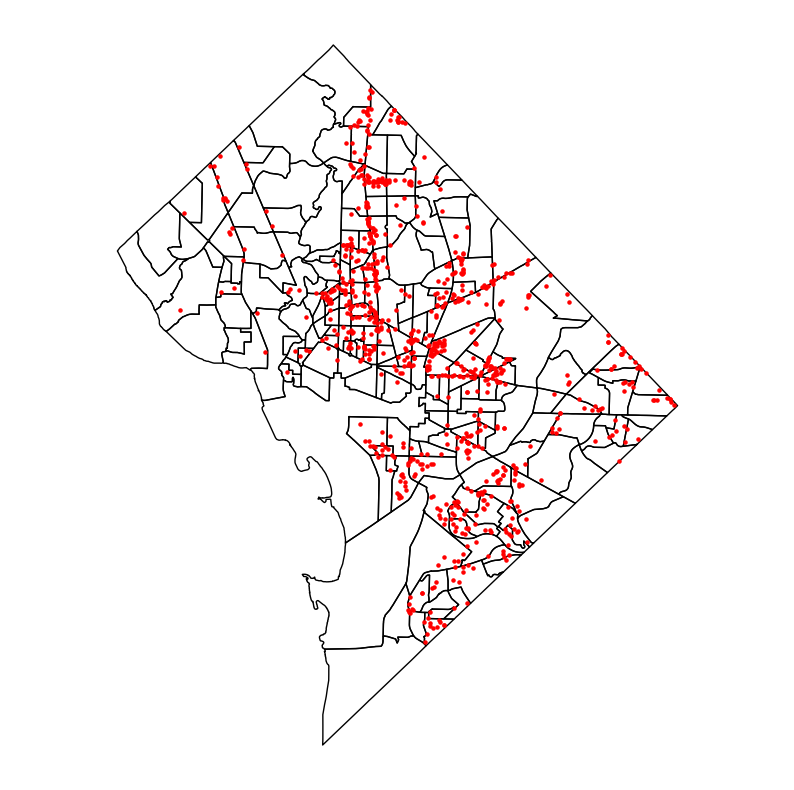

In [13]:
# Plot affordable housing projects overlaid on tracts

fig, ax = plt.subplots(figsize=(10, 10))
ax = tracts.plot(ax=ax, facecolor='none', edgecolor='k', zorder=0)
affordable_housing.plot(ax=ax, markersize=5, color='r', zorder=1)
ax.axis('off')
plt.axis('equal')

plt.savefig('large_scale_map.eps')

plt.show()

In [14]:
# Make sure that both geodataframes have the same coordinate system
assert tracts.crs == affordable_housing.crs

In [16]:
# Count affordable units per tract
# (gpd.sjoin tracts to affordable housing points, then join counts to tracts)

# join tracts to projects
affordable_housing_with_tracts = gpd.sjoin(affordable_housing, tracts, how='left')

# count units per tract
units_per_tract = affordable_housing_with_tracts.groupby('geoid').agg({'TOTAL_AFFORDABLE_UNITS':['sum','min','max','count']})

# attach unit counts to tract geometries
units_per_tract = units_per_tract.droplevel(0, axis=1)
units_per_tract = units_per_tract.reset_index()
units_per_tract = tracts.merge(units_per_tract, on='geoid', how='left')
units_per_tract = units_per_tract.fillna(0)

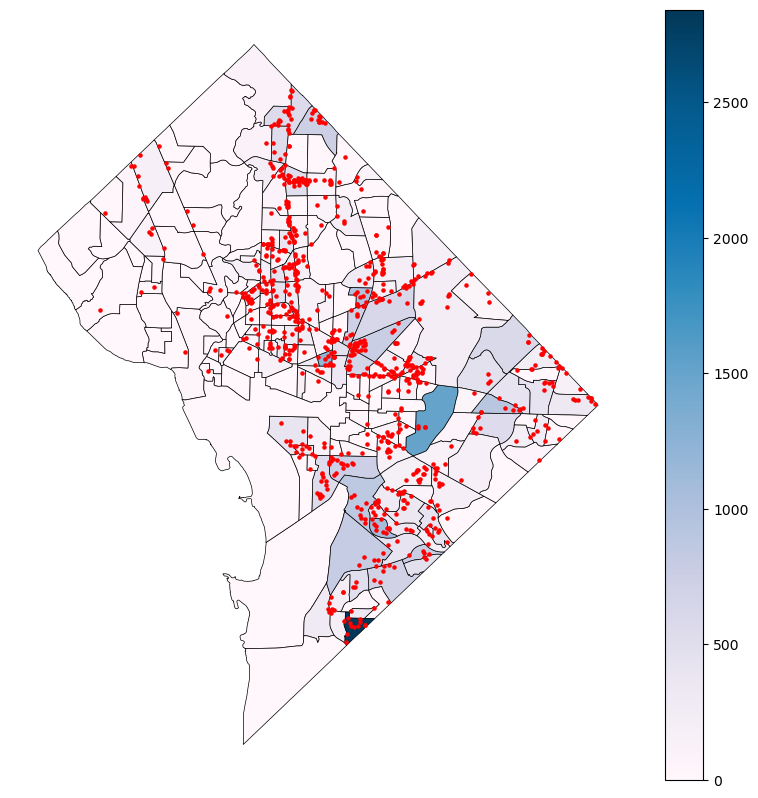

In [17]:
# Plot choropleth map with unit counts

fig, ax = plt.subplots(figsize=(10, 10))
ax = units_per_tract.plot(ax=ax, column='sum', cmap='PuBu', linewidth=0.5, edgecolor='black', legend=True)
affordable_housing.plot(ax=ax, markersize=5, color='r', zorder=1)
ax.axis('off')

plt.savefig('large_scale_map.eps')

plt.show()

In [18]:
# Standardize unit counts by population
units_per_tract['units_per_pop'] = units_per_tract['sum'] / units_per_tract['B01003001']

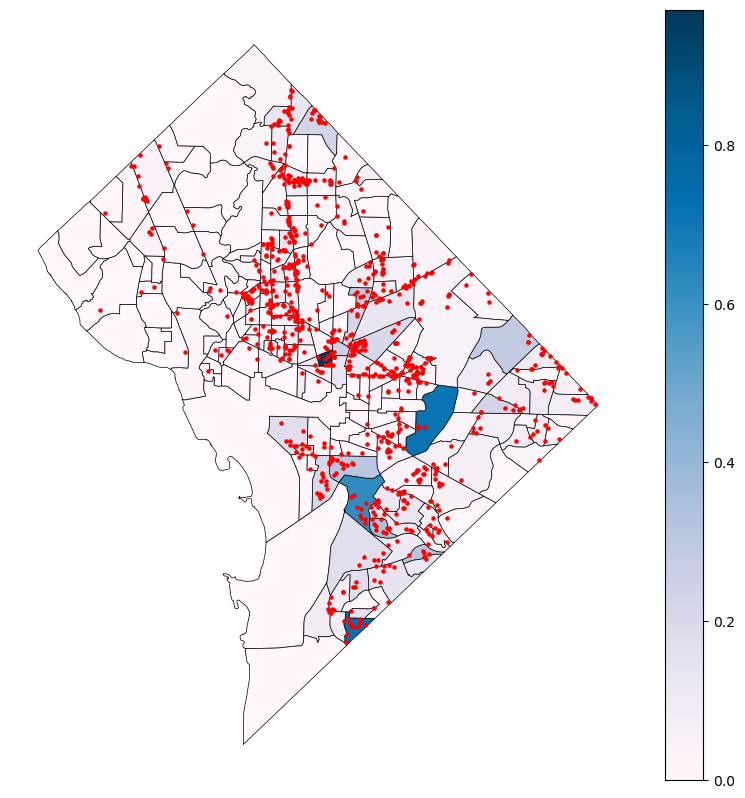

In [19]:
# Plot choropleth map with standardized project counts

fig, ax = plt.subplots(figsize=(10, 10))
ax = units_per_tract.plot(ax=ax, column='units_per_pop', cmap='PuBu', linewidth=0.5, edgecolor='black', legend=True)
affordable_housing.plot(ax=ax, markersize=5, color='r', zorder=1)
ax.axis('off')

plt.savefig('large_scale_map.eps')

plt.show()

### Proportional Symbol Map

An elegant way to map counts without biasing by the areas of spatial units is to use proportional symbols. This script calculates the radii (buffer distances) for circular symbols with areas proportional to input counts. 

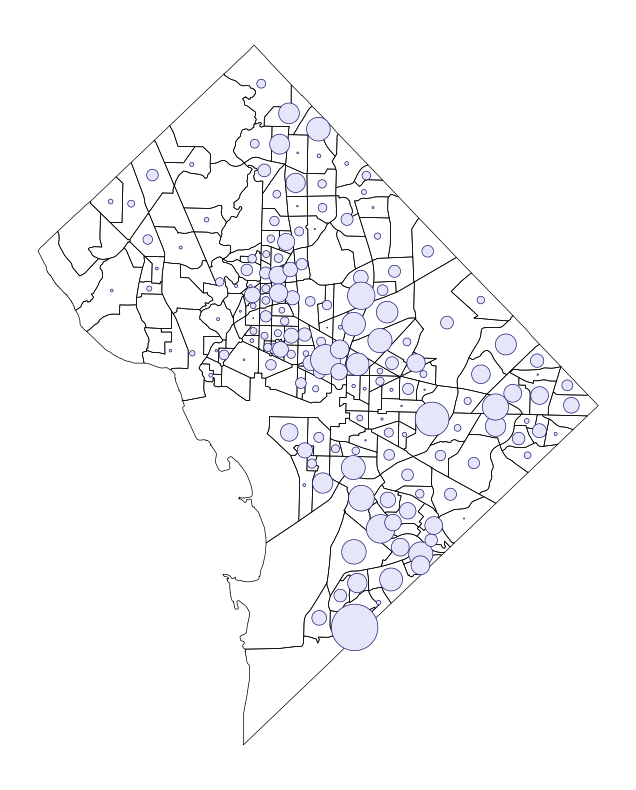

In [20]:
tract_points = units_per_tract.copy()
tract_points['geometry'] = tract_points.centroid

def proportional_circles_radii(values, multiplier=1):
    return np.sqrt(values / 3.14) * multiplier

fig, ax = plt.subplots(figsize=(10, 10))
ax = tracts.plot(ax=ax, facecolor='none', edgecolor='black', zorder=0, linewidth=0.5)

tract_points.buffer(proportional_circles_radii(tract_points['sum'], 25)).plot(
    ax=ax, 
    zorder=1, 
    facecolor='lavender', 
    edgecolor='midnightblue', 
    linewidth=0.5)
# affordable_housing.plot(ax=ax, markersize=1, color='darkblue', zorder=2)
ax.axis('off')

plt.savefig('large_scale_map.eps')

plt.show()

## Contextly can automatically add a basemap for reference

`pip install contextily`

In [21]:
import contextily as cx

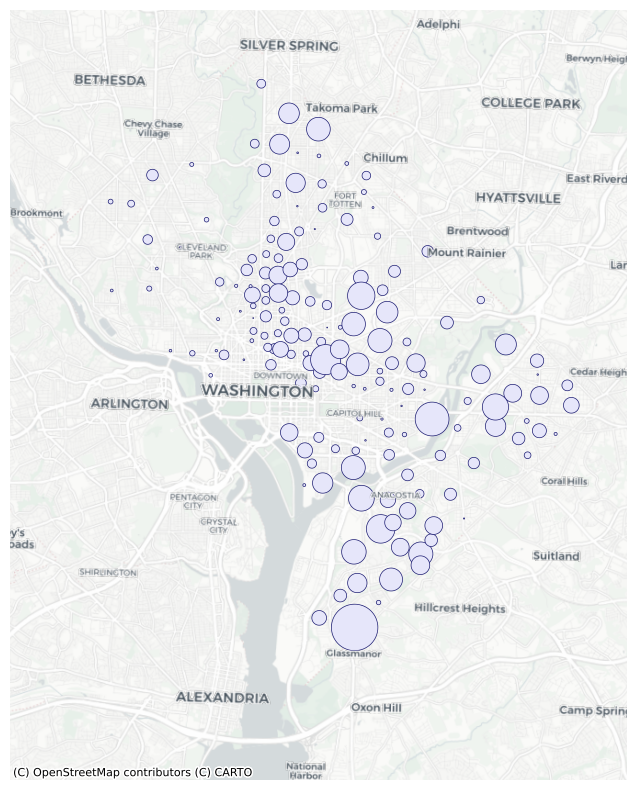

In [23]:
tract_points = units_per_tract.copy()
tract_points['geometry'] = tract_points.centroid

def proportional_circles_radii(values, multiplier=1):
    return np.sqrt(values / 3.14) * multiplier

fig, ax = plt.subplots(figsize=(10, 10))
ax = tracts.plot(ax=ax, facecolor='none', edgecolor='black', zorder=0, linewidth=0.5)

tract_points.buffer(proportional_circles_radii(tract_points['sum'], 25)).plot(
    ax=ax, 
    zorder=1, 
    facecolor='lavender', 
    edgecolor='midnightblue', 
    linewidth=0.5)
# affordable_housing.plot(ax=ax, markersize=1, color='darkblue', zorder=2)
ax.axis('off')

# Base map with labels embedded
cx.add_basemap(ax, crs=utm18, source=cx.providers.CartoDB.Positron, zorder=0)

# Base map with labels overlaid
cx.add_basemap(ax, crs=utm18, source=cx.providers.CartoDB.PositronNoLabels, zorder=0)
cx.add_basemap(ax, crs=utm18, source=cx.providers.CartoDB.PositronOnlyLabels, zorder=3)

plt.savefig('large_scale_map.eps')

plt.show()

## Folium

To make an interactive map with the popular [Leaflet.js](https://leafletjs.com/reference) JavaScript library, we can use Folium.

`pip install folium`

In [24]:
import folium

In [25]:
affordable_housing = gpd.read_file('affordable_housing.geojson')
tracts = gpd.read_file('dc_tracts.geojson')

# Project into lat and long (WGS84)
affordable_housing = affordable_housing.to_crs(4326)
tracts = tracts.to_crs(4326)

# Drop column with timestamps because they interfere with Folium
affordable_housing = affordable_housing.drop(columns=['GIS_LAST_MOD_DTTM'])

# Identify map center
lon_min, lat_min, lon_max, lat_max = tracts.total_bounds
lon_center = (lon_max + lon_min) / 2
lat_center = (lat_max + lat_min) / 2

# Initiate map
map = folium.Map(location=(lat_center, lon_center), zoom_start=12)
# map = folium.Map(location=(lat_center, lon_center), zoom_start=12, tiles="Cartodb Positron")

# Add tracts
tract_style = {
    'weight': 1,
    'color': 'black',
    'fillColor': '#00000000',
    'fillOpacity': 1,
    }
folium.GeoJson(data=tracts.to_json(), style_function=lambda x: tract_style).add_to(map)

# Add affordable housing points
circle_marker = folium.CircleMarker(radius = 4, weight = 1, color='white', fillColor = 'darkblue', fill_opacity=1)
affordable_housing_points = folium.GeoJson(affordable_housing.to_json(), marker=circle_marker)
folium.features.GeoJsonPopup(fields=['PROJECT_NAME','TOTAL_AFFORDABLE_UNITS'], labels=True).add_to(affordable_housing_points)
affordable_housing_points.add_to(map)

# map
map.save('map.html')

## GeoPandas `explore`

To make life just a little easier, GeoPandas has a built-in method for making a Folium map with `explore`.

In [26]:
m = tracts.explore(
    tiles='CartoDB positron',
    attr='MapBox CartoDB positron',
    style_kwds={
        'weight': 1,
        'color': 'black',
        'fillColor': '#00000000',
        'fillOpacity': 1,
    },
)

m = affordable_housing.explore(
    m=m,
    marker_kwds={
        'radius':4, 
        'weight':1, 
        'color':'white', 
        'fillColor':'darkblue', 
        'fill_opacity':1
    },
)

m.save('map_explore.html')

## CartoPy

If you're making a smaller-scale map of a state, country, or continent (can you guess why the scale is called "smaller"?) you may need to use a specialized projection to avoid distortion or preserve particular qualities (e.g., using an equidistant projection to allow for measurement between distant points).

A package called CartoPy enables mapping in Python with nearly any projection. It also allows you to access convenient base layers from [Natural Earth](https://www.naturalearthdata.com/), a free database of global basemap data for cultural (e.g., borders) and physical (e.g., coastlines) features.

`pip install cartopy`

In [27]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

/Users/cwharvey/opt/anaconda3/envs/688y/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/cwharvey/opt/anaconda3/envs/688y/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/cwharvey/opt/anaconda3/envs/688y/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/cwharvey/opt/anaconda3/envs/688y/lib/python3.13/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/cwharvey/opt/anaconda3/envs/688y/lib/python3.13/site-packages

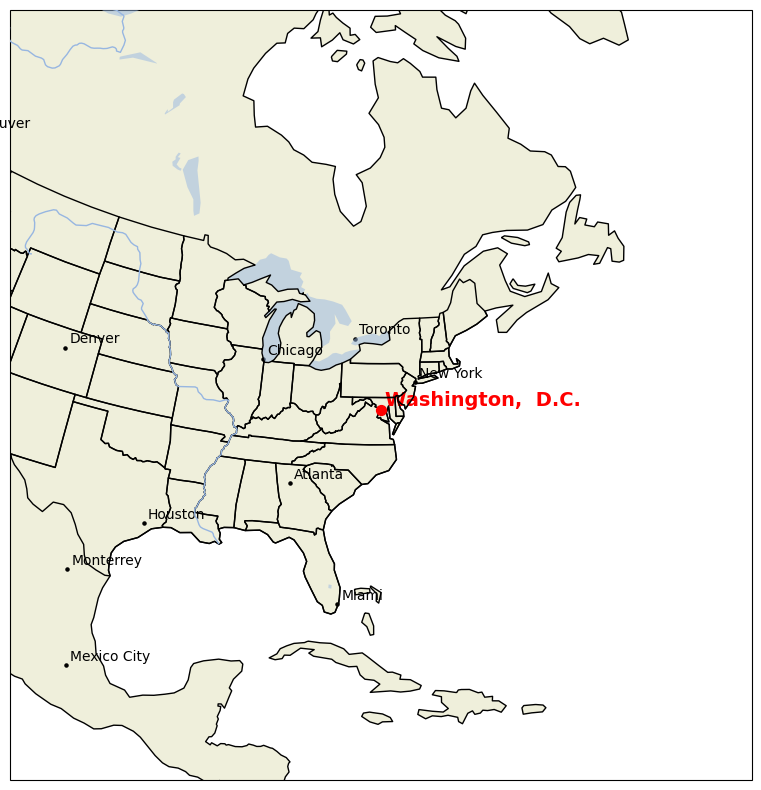

In [29]:
# Define highlight city
highlight_city = 'Washington,  D.C.'
# highlight_city = 'Chicago'

# Load city points
pop_places = gpd.read_file('ne_10m_populated_places_simple.zip')

# Define map center and extents around the highlight city
lon_center = pop_places[pop_places['name'] == highlight_city].geometry.x.iloc[0]
lat_center = pop_places[pop_places['name'] == highlight_city].geometry.y.iloc[0]
extent = 50
lon_min = lon_center + (extent / 2)
lon_max = lon_center - (extent / 2)
lat_min = lat_center - (extent / 2)
lat_max = lat_center + (extent / 2)

# Define projection centered on highlight city
crs = ccrs.AzimuthalEquidistant(central_longitude=lon_center, central_latitude=lat_center)

# Project cities into axis coordinate system
pop_places = pop_places.to_crs(crs.proj4_init)

# Constrain to cities only one rank lower than the highlight
rank = pop_places[pop_places['name'] == highlight_city].scalerank.iloc[0] + 1
pop_places = pop_places[pop_places.scalerank <= rank]

# Initiate figure
fig = plt.figure(figsize=(15, 10))

# Initiate axis with defined projection
ax = plt.subplot(1, 1, 1, projection=crs)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='blue', linestyle='--', zorder=0)
ax.add_feature(cfeature.LAND, zorder=1)
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=3)
ax.add_feature(cfeature.STATES, zorder=4)
ax.add_feature(cfeature.RIVERS, zorder=5)

# Add city points
pop_places.plot(ax=ax, markersize=5, color='k', zorder=1)
pop_places[pop_places['name'] == highlight_city].plot(ax=ax, markersize=50, color='r', zorder=6)

# Label cities
def annotate(record):
    if record['name'] == highlight_city:
        ax.annotate(record['name'], weight='bold', size=14, color='red', xy=record.geometry.coords[0], xytext=(3, 3), textcoords='offset points', clip_on=True)
    else:
        ax.annotate(record['name'], xy=record.geometry.coords[0], xytext=(3, 3), textcoords='offset points', clip_on=True)
pop_places.apply(annotate, axis=1)

plt.savefig('small_scale_map.eps', format='eps')

plt.show()